### **Introduction**
This data analysis utilizes a dataset containing life expectancy and GDP data for five countries over multiple years. By examining both temporal and cross-country variations, the study seeks to uncover patterns that illustrate how improvements in economic growth may correspond to changes in population health outcomes.

#### **Project Scope**

- Investigates the relationship between life expectancy and economic performance (GDP) across five countries over multiple years.  
- Analyzes data patterns to understand how economic growth influences population health outcomes.  
- Summarizes and visualizes key statistics using tables, line plots, bar charts, and box plots to highlight variations and trends across time and countries.  
- Explores relationships between GDP and life expectancy through scatter plots, trend analysis, and correlation measures.  
- Applies statistical methods to evaluate the significance and strength of observed relationships between economic and health indicators.  
- Builds predictive models (e.g., regression) to estimate life expectancy based on GDP and time, assessing accuracy and reliability.  
- Combines data visualization, statistical analysis, and predictive modeling to deliver insights on the socioeconomic factors shaping global health and longevity.  


#### Data Overview
The dataset consists of 96 observations and four key attributes representing annual life expectancy and GDP data for six countries. It combines both cross-sectional and time-series characteristics, enabling comparative and trend-based analyses. The dataset comprises one categorical variable and three numeric variables:

- Categorical variable: Country
- Numeric variable: Year, Life expectancy at birth (years), GDP

The categorical data, Country consist of:

1. Chile
2. China
3. Germany
4. Mexico
5. United States of America
6. Zimbabwe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import plotly.express as px
from pathlib import Path
import seaborn as sns
import scipy.stats as stats

life_data = pd.read_csv('all_data.csv')
life_data.info()
life_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


Loading the CSV dataset and checking the data types containing life expectancy, years and GDP.

Data cleaning:
- Rename 'Life expectancy at birth (years)' to 'Life_expectancy_years'
- Update the country name from 'United States of America' to 'USA'.
- Convert GDP by dividing the column value by 1e9
- A new column 'GDP_in_billion' is created to handle large values of GDP

In [2]:
life_data.rename(columns={'Life expectancy at birth (years)': 'Life_expectancy_years'}, inplace=True)
life_data['Country'] = life_data['Country'].replace({'United States of America': 'USA'})
life_data['GDP_in_trillion'] = life_data['GDP'] / 1e12
# life_data.drop(columns=['GDP'], inplace=True)


#### Summary statistics
This stage focuses on identifying central tendencies, dispersion, and overall trends to build an initial understanding of the data before deeper exploration and modeling.
These statistics provide insight into the range and variability of life expectancy and GDP across all observations. 
- The mean and standard deviation help establish the central tendency and spread of each variable, 
- Minimum and Maximum values indicate the observed extremes across the dataset.
- Average of Life expectancy and GDP across the five selected countries


General Summary statistics (GDP Vs Life expectancy):

In [3]:
life_data.describe()[['Life_expectancy_years', 'GDP_in_trillion']]

,Life_expectancy_years,GDP_in_trillion
count,96.000000,96.000000
mean,72.789583,3.880499
std,10.672882,5.197561
min,44.300000,0.004416
25%,74.475000,0.173302
50%,76.750000,1.280220
75%,78.900000,4.067510
max,81.000000,18.100000


Summary statistics per Country:
1. variance
2. standard deviation
3. mean absolute deviation
4. mean
5. mode
6. median

In [4]:
summary_stats = life_data.groupby('Country')[['Life_expectancy_years', 'GDP_in_trillion']].agg(['var', 'std', 'mean', 'median']).reset_index()

summary_stats

Country Life_expectancy_years                            GDP_in_trillion  \
                              var       std      mean median             var   
0     Chile              1.121292  1.058911  78.94375  79.00        0.005910   
1     China              1.737167  1.318016  74.26250  74.45       12.257672   
2   Germany              0.950625  0.975000  79.65625  79.85        0.445538   
3    Mexico              0.385625  0.620987  75.71875  75.65        0.043920   
4       USA              0.693167  0.832566  78.06250  78.15        5.918000   
5  Zimbabwe             35.287292  5.940311  50.09375  47.40        0.000018   

                                   
        std       mean     median  
0  0.076879   0.169789   0.172997  
1  3.501096   4.957714   4.075195  
2  0.667486   3.094776   3.396350  
3  0.209572   0.976651   1.004375  
4  2.432694  14.075000  14.450000  
5  0.004298   0.009063   0.006734

Calculating frequency per Country:

In [5]:
life_data['Country'].value_counts()

Country
Chile       16
China       16
Germany     16
Mexico      16
USA         16
Zimbabwe    16
Name: count, dtype: int64

##### Compare GDP Vs Life Expectancy
The 'groupby' function highlights the average life expectancy and GDP for each country, offering a quick comparison of relative economic performance and health outcomes.
- Germany has the highest average life expectancy with Zimbabwe recording the lowest average over time.
- USA has the highest average GDP of 14.8 trillion dollars over time with Zimbabwe having the lowest 0.01 trillion dollars.

In [6]:
life_data.groupby('Country')[['Life_expectancy_years', 'GDP_in_trillion']].mean().round(2)

,Life_expectancy_years,GDP_in_trillion
Country,,
Chile,78.94,0.17
China,74.26,4.96
Germany,79.66,3.09
Mexico,75.72,0.98
USA,78.06,14.08
Zimbabwe,50.09,0.01


Mininum and Maximum of Life expectancy and GDP respectively per country between 2000 and 2015

In [7]:
print("==== Life Expectancy per country ====")
for country in life_data['Country'].unique():
    country_data = life_data[life_data['Country'] == country]
    print(f"{country}: ", "min= "+ str(int(country_data['Life_expectancy_years'].min())), ", max= "+ str(int(country_data['Life_expectancy_years'].max())))

print("\n==== GDP per country ====")
for country in life_data['Country'].unique():
    country_data = life_data[life_data['Country'] == country]
    print(f"{country}: ", "min= "+ str(float(round(country_data['GDP_in_trillion'].min(), 4))), ", max= "+ str(float(round(country_data['GDP_in_trillion'].max(), 4))))      

==== Life Expectancy per country ====
Chile:  min= 77 , max= 80
China:  min= 71 , max= 76
Germany:  min= 78 , max= 81
Mexico:  min= 74 , max= 76
USA:  min= 76 , max= 79
Zimbabwe:  min= 44 , max= 60

==== GDP per country ====
Chile:  min= 0.0697 , max= 0.2784
China:  min= 1.2114 , max= 11.0647
Germany:  min= 1.95 , max= 3.8906
Mexico:  min= 0.6836 , max= 1.2985
USA:  min= 10.3 , max= 18.1
Zimbabwe:  min= 0.0044 , max= 0.0163


GDP descriptive statistics:

In [8]:
def mad(x):
    # mean absolute deviation from the mean
    return np.mean(np.abs(x - x.mean()))

def mode(x):
    m = x.mode()
    if not m.empty:
        return m.iloc[0]
    else:
        return np.nan
    
def data_range(x):
    return x.max() - x.min()

stats_df = life_data.groupby("Country").agg({
    'GDP_in_trillion': ['mean',mode, data_range, 'median', mad, 'var', 'std']
}).reset_index()

print(stats_df)

    Country GDP_in_trillion                                             \
                       mean       mode data_range     median       mad   
0     Chile        0.169789   0.069737   0.208647   0.172997  0.064667   
1     China        4.957714   1.211350   9.853350   4.075195  2.974249   
2   Germany        3.094776   1.949950   1.940660   3.396350  0.561856   
3    Mexico        0.976651   0.683648   0.614812   1.004375  0.181646   
4       USA       14.075000  10.300000   7.800000  14.450000  1.978125   
5  Zimbabwe        0.009063   0.004416   0.011889   0.006734  0.003719   

                        
         var       std  
0   0.005910  0.076879  
1  12.257672  3.501096  
2   0.445538  0.667486  
3   0.043920  0.209572  
4   5.918000  2.432694  
5   0.000018  0.004298  


Life expectancy descriptive statistics:

In [9]:
stats_df = life_data.groupby("Country").agg({
    'Life_expectancy_years': ['mean',mode, data_range, 'median', mad, 'var', 'std']
}).reset_index()

print(stats_df)

    Country Life_expectancy_years                                    \
                             mean  mode data_range median       mad   
0     Chile              78.94375  77.3        3.2  79.00  0.881250   
1     China              74.26250  71.7        4.4  74.45  1.067188   
2   Germany              79.65625  80.6        3.0  79.85  0.811719   
3    Mexico              75.71875  75.0        1.9  75.65  0.508594   
4       USA              78.06250  77.5        2.5  78.15  0.717187   
5  Zimbabwe              50.09375  44.3       16.4  47.40  5.154688   

                        
         var       std  
0   1.121292  1.058911  
1   1.737167  1.318016  
2   0.950625  0.975000  
3   0.385625  0.620987  
4   0.693167  0.832566  
5  35.287292  5.940311  


The data visualization in Fig. 1 illustrates the distribution of life expectancy across countries, highlighting both the median and the variability.
Meanwhile, the boxplot in Fig. 2 uses a logarithmic scale to compare GDP levels across countries with different economic sizes more effectively. This approach helps to explore whether higher GDPs are associated with higher or more stable life expectancy values.

Results:
- Countries like Chile, China, Germany, and the USA show narrow boxes, indicating low variation in life expectancy over time. This suggests that life expectancy remained relatively stable in these countries, with overall high values.
- Conversely, a wider box for Zimbabwe indicates greater fluctuations in life expectancy, reflecting improvements over time. Although Zimbabwe's life expectancy remains the lowest among the countries analyzed, ranging between 44 and 60 years, it recorded improvement which could be clearly seen through the time series plot 'lineplot'.
- Germany, Mexico, and the USA exhibit very low variation in GDP over the years, with no extreme spikes among higher-income observations.
- China shows a steady increase in GDP, with moderate variation over time.
- Zimbabwe has the lowest GDP, with a small difference between the median and the 25th percentile.
- Overall, countries with relatively high GDPs, such as the USA, Germany, Mexico, and China, tend to have correspondingly higher life expectancy.



Side by side boxplot (Life expectancy Vs GDP)

/var/folders/3w/7_wgs56n3c30fpsrg0g2mg_00000gn/T/ipykernel_93216/1168487171.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=life_data, x='Country', y='Life_expectancy_years', palette='Set2', showmeans=True)
/var/folders/3w/7_wgs56n3c30fpsrg0g2mg_00000gn/T/ipykernel_93216/1168487171.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=life_data, x='Country', y='GDP', palette='Set3')


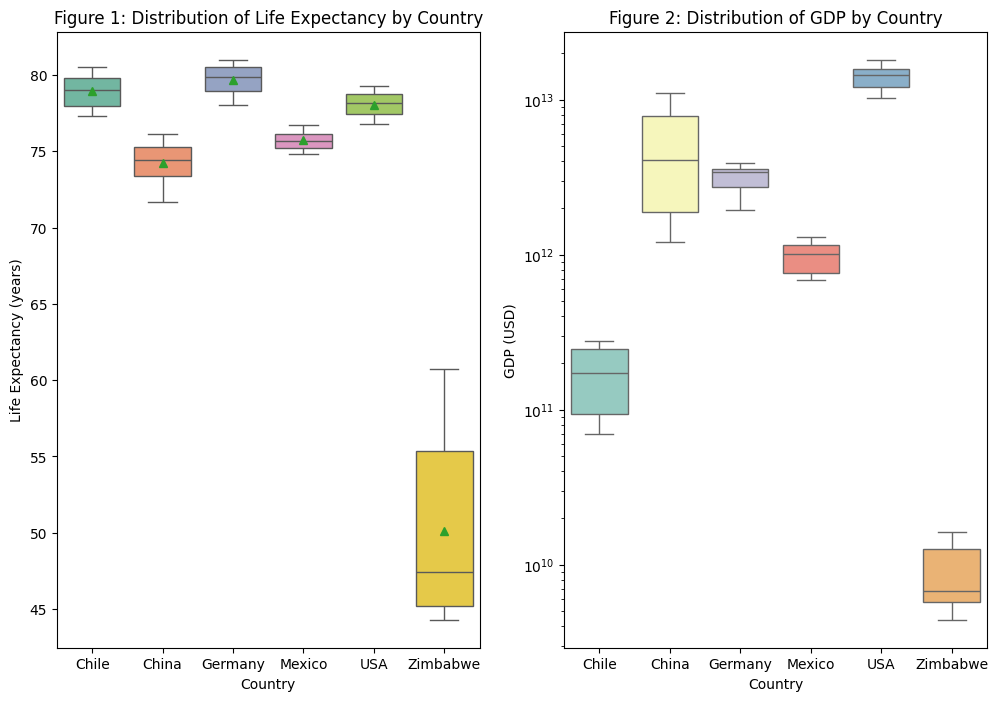

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.boxplot(data=life_data, x='Country', y='Life_expectancy_years', palette='Set2', showmeans=True)
plt.title('Figure 1: Distribution of Life Expectancy by Country')
plt.xlabel('Country')
plt.ylabel('Life Expectancy (years)')

plt.subplot(1,2,2)
sns.boxplot(data=life_data, x='Country', y='GDP', palette='Set3')
plt.title('Figure 2: Distribution of GDP by Country')
plt.xlabel('Country')
plt.ylabel('GDP (USD)')
plt.yscale('log')  # Log scale for better visualization

plt.show()

Check the year interval

In [11]:
print(sorted(life_data.Year.unique().tolist()) )

[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]


##### Time Series (GDP vs Life Expectancy)

The next visualization examines how life expectancy and GDP evolved from 2000 to 2015. The line plot highlights the trends and provides deeper insight into how both indicators changed over time.

Results:
- There was a steady drop in life expectancy for Zimbabwe between 2000 and 2004 but observed upward trajectory between 2004 and 2015
- Other countries like USA, China, Chile, Mexico and Germany observed slight rise and drop in both Life expectancy and GDP
- Zimbabwe observed a drop in GDP between 2000 and 2008 and picked up between 2008 and 2015

Side by side Lineplot:

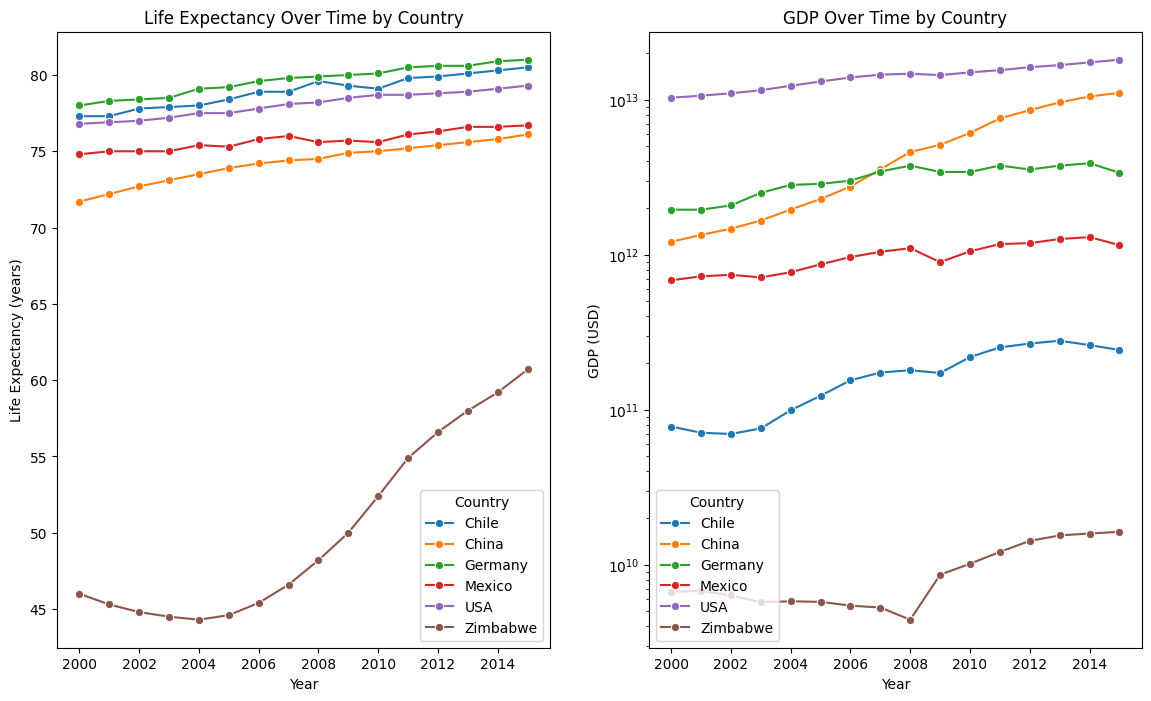

In [12]:
plt.figure(figsize=(14,8))
ax1 = plt.subplot(1,2,1)
sns.lineplot(data=life_data, x='Year', y='Life_expectancy_years', hue='Country', marker='o')
plt.title('Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (years)')
plt.legend(title='Country')

plt.subplot(1,2,2)
sns.lineplot(data=life_data, x='Year', y='GDP', hue='Country', marker='o')
plt.title('GDP Over Time by Country')
plt.xlabel('Year')
plt.ylabel('GDP (USD)')
plt.yscale('log')
plt.legend(title='Country')

plt.show()




##### Trend analysis (Average per country)

The data is organized with countries as the index and years as the columns, while GDP and life expectancy serve as the summarized values by using a pivot table. The objective is to:

- Get the average of GDP and Life expectancy per country, line them up in a Lineplot and observe the trends.
- Compare the data of the country-level plot with and without the average of GDP and Life expectancy.
- A Lineplot is used to visualize the trends between GDP and Life Expectancy over the period of 15 years.

Pivotting the dataset:

In [13]:
df_pivot = life_data.pivot_table(
    index='Country', 
    columns='Year', 
    values=['GDP', 'Life_expectancy_years'], 
    aggfunc='mean'
)
df_pivot.head()

GDP                                                          \
Year             2000          2001          2002          2003          2004   
Country                                                                         
Chile    7.786093e+10  7.097992e+10  6.973681e+10  7.564346e+10  9.921039e+10   
China    1.211350e+12  1.339400e+12  1.470550e+12  1.660290e+12  1.955350e+12   
Germany  1.949950e+12  1.950650e+12  2.079140e+12  2.505730e+12  2.819250e+12   
Mexico   6.836480e+11  7.247040e+11  7.415600e+11  7.132840e+11  7.702680e+11   
USA      1.030000e+13  1.060000e+13  1.100000e+13  1.150000e+13  1.230000e+13   

                                                                               \
Year             2005          2006          2007          2008          2009   
Country                                                                         
Chile    1.229650e+11  1.547880e+11  1.736060e+11  1.796380e+11  1.723890e+11   
China    2.285970e+12  2.752130e+12  3.552180e+12  4.598210e+12  5.109950e+12   
Germany  2.861410e+12  3.002450e+12  3.439950e+12  3.752370e+12  3.418010e+12   
Mexico   8.663460e+11  9.652810e+11  1.043470e+12  1.101280e+12  8.949490e+11   
USA      1.310000e+13  1.390000e+13  1.450000e+13  1.470000e+13  1.440000e+13   

         ... Life_expectancy_years                                            \
Year     ...                  2006  2007  2008  2009  2010  2011  2012  2013   
Country  ...                                                                   
Chile    ...                  78.9  78.9  79.6  79.3  79.1  79.8  79.9  80.1   
China    ...                  74.2  74.4  74.5  74.9  75.0  75.2  75.4  75.6   
Germany  ...                  79.6  79.8  79.9  80.0  80.1  80.5  80.6  80.6   
Mexico   ...                  75.8  76.0  75.6  75.7  75.6  76.1  76.3  76.6   
USA      ...                  77.8  78.1  78.2  78.5  78.7  78.7  78.8  78.9   

                     
Year     2014  2015  
Country              
Chile    80.3  80.5  
China    75.8  76.1  
Germany  80.9  81.0  
Mexico   76.6  76.7  
USA      79.1  79.3  

[5 rows x 32 columns]

Next step is to apply the stack function to move the 'Year' column level into the row index, transforming the dataset wide-format into a long-format data structure. Specifically, we will:

- Stack the data at level 1 (the second-level column index corresponding to 'Year') to pivot it into the row index
- Rename the resulting columns (GDP and Life_expectancy) to indicate that they represent average values
- Reset the index to finalize the long-format structure

Stacking the dataset:


In [14]:
df_pivot = df_pivot.stack(level=1).rename(
    columns={'GDP': 'Avg_GDP', 'Life_expectancy_years': 'Avg_Life_expectancy'}
).reset_index()

df_pivot.head()

/var/folders/3w/7_wgs56n3c30fpsrg0g2mg_00000gn/T/ipykernel_93216/1543481265.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_pivot = df_pivot.stack(level=1).rename(


,Country,Year,Avg_GDP,Avg_Life_expectancy
0,Chile,2000,7.786093e+10,77.3
1,Chile,2001,7.097992e+10,77.3
2,Chile,2002,6.973681e+10,77.8
3,Chile,2003,7.564346e+10,77.9
4,Chile,2004,9.921039e+10,78.0


##### Summary of Key Descriptive Insights
- The time-series line plot of the average GDPs per country appears to diverge from the original country-level plots in several places, indicating that there may be anomalies or outliers affecting the averaged values. However, this discrepancy in the data needs to be proved.
- The line plot of the average life expectancy closely follows the individual country-level trends, suggesting that there are no noticeable anomalies in the life expectancy data.

Note: The deviations will be studied in the Exploration Data Analysis section of this project.

Plotting average GDP & Life expectancy per year:

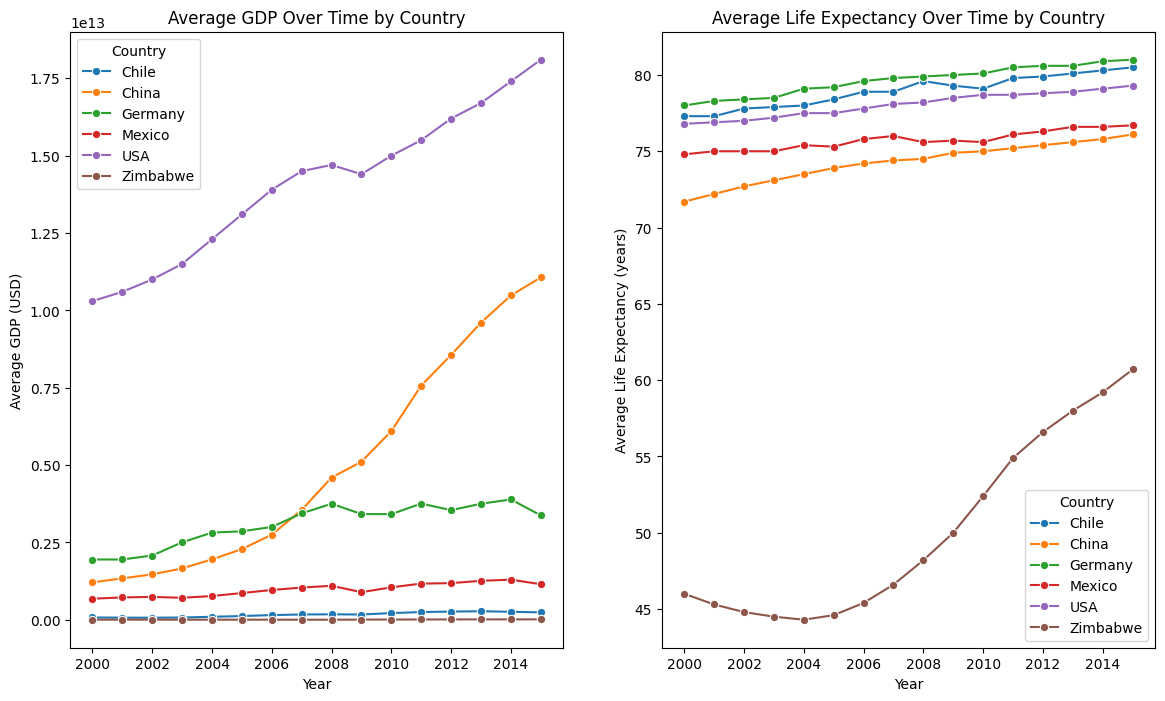

In [15]:
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
sns.lineplot(data=df_pivot, x='Year', y='Avg_GDP', hue='Country', marker='o')
plt.title('Average GDP Over Time by Country')
plt.xscale
plt.xlabel('Year')
plt.ylabel('Average GDP (USD)')
plt.legend(title='Country') 

plt.subplot(1,2,2)
sns.lineplot(data=df_pivot, x='Year', y='Avg_Life_expectancy', hue='Country', marker='o')
plt.title('Average Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (years)')
plt.legend(title='Country')
plt.show()

#### Exploratory Data Analysis (EDA)
Exploratory Data Analysis aims to uncover underlying patterns, relationships, and anomalies within the dataset. In this stage, we go beyond summary statistics to visually and quantitatively examine how economic performance (GDP) and life expectancy interact across different countries and time periods.

The objectives of this analysis are to:
- Explore the relationship between life expectancy and GDP.
- Identify correlation strength and direction between the two variables.
- Detect potential outliers or deviations from general trends.
- Visualize cross-country and temporal variations.

Interpretation:

A positive correlation suggests that as GDP increases, life expectancy also tends to rise. The strength of this correlation indicates how closely linked economic prosperity and life expectancy outcomes are across the observed countries and years. Earlier, we calculated an overall correlation of 0.343 across all countries, which is weaker than the correlations observed at the individual country level.

Results:
- The correlation value of individual country shows a very strong positive correlation indicating linearity
- The scatter plot displayed below illustrates how life expectancy changes with increasing GDP


Correlation Measure (GDP and Life Expectancy):

In [16]:
# Compute the Pearson correlation coefficient
corr_value = life_data['Life_expectancy_years'].corr(life_data['GDP'])
print(f"Correlation between GDP and Life Expectancy: {corr_value:.3f}")

Correlation between GDP and Life Expectancy: 0.343


##### Relationship between GDP and Life expectancy per Country
This analysis illustrates the correlation/relationship between GDP and life expectancy for each country compared to the overall correlation across all countries.

Interpretation:

- In the table below, obtained from groupby function shows how the relationship between GDP and life expectancy varies across countries. A stronger correlation for certain countries might reflect consistent socioeconomic improvements, whereas weaker correlations may indicate additional factors influencing life expectancy like the GDP of a country.
- This scatter plot illustrates how life expectancy changes with increasing GDP. 

Results of the analysis below:
- The observed correlation values indicate that there is a strong positive correlation between each country's GDP and Life expectancy.
- USA has the highest correlation value of 0.982 while Mexico has the lowest with the value of 0.932
- In the scatter plot, countries clustering along an upward trajectory indicate a strong positive association.
- Zimbabwe’s GDP shows a slight initial decline over the period, followed by a sharp recovery, although overall changes remain relatively small.

Correlation Measure per country:

In [17]:
country_corr = life_data.groupby('Country')[['GDP', 'Life_expectancy_years']].corr().unstack().iloc[:,1].round(3)
country_corr

Country
Chile       0.950
China       0.909
Germany     0.933
Mexico      0.932
USA         0.982
Zimbabwe    0.966
Name: (GDP, Life_expectancy_years), dtype: float64

Scatter Plot (GDP vs. Life Expectancy) per country : 

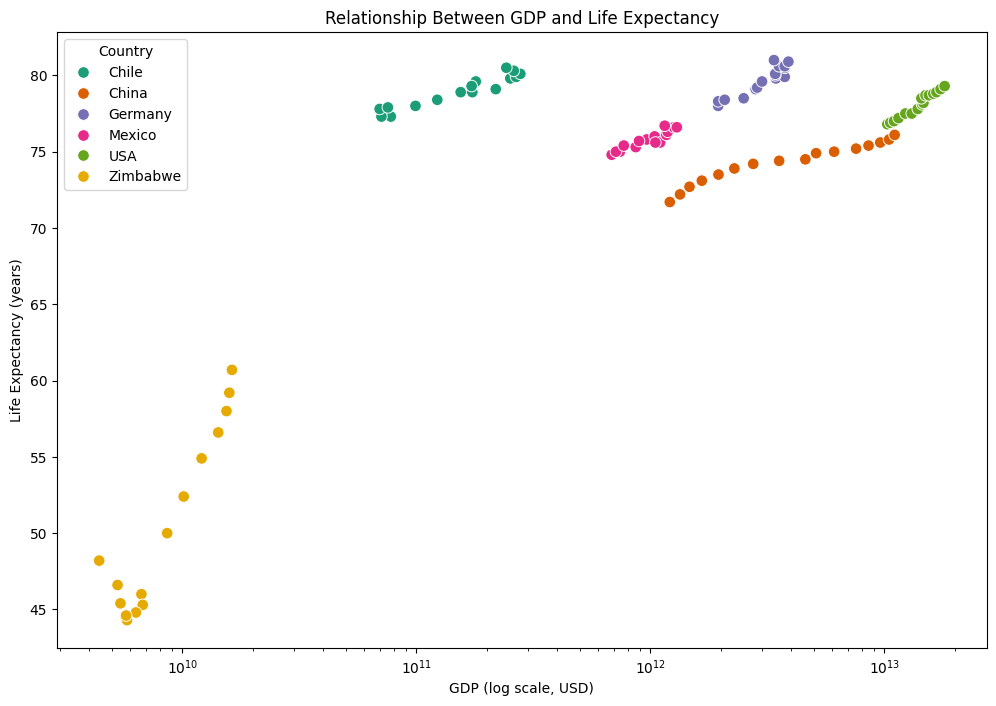

In [18]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=life_data, x='GDP', y='Life_expectancy_years', hue='Country', palette='Dark2', s=70)
plt.xscale('log')  # Log scale for GDP to manage large range differences
plt.title('Relationship Between GDP and Life Expectancy')
plt.xlabel('GDP (log scale, USD)')
plt.ylabel('Life Expectancy (years)')
plt.legend(title='Country')
plt.show()

#### Outlier detection
Firstly, we check if there are outliers in GDP and Life expectancy per country in the dataset. Previous data analysis of the average GDP and Life expectancy suggested that there might be the presence of outliers clearly shown in the lineplot.
Here, we do the following to check the presence of outliers:

- Check the lower and upper bound of the GDP and Life expectancy per country
- Filter the dataset for the lower and upper bound
- Validate the dataset if there was outlier or not in GDP and life expectancy per country


The analysis indicates that no outliers were detected in the GDP or life expectancy data for any country. The minor deviations observed in the earlier line plot are likely attributable to small gaps in the recorded GDP and life expectancy values. These gaps may account for the observed differences between the datasets with and without averaging.

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]
    
    # If no outliers, set explicitly to "No Outliers"
    if outliers.empty:
        outliers_result = "No Outliers"
    else:
        outliers_result = outliers

    return outliers_result, lower, upper

# Dictionary to store results
outlier_results = {}

# Loop per country
for country, group in life_data.groupby("Country"):

    country_stats = {}

    for col in ['GDP', 'Life_expectancy_years']:
        outliers, lower, upper = detect_outliers_iqr(group, col)

        country_stats[col] = {
            "Number of Outliers": 0 if outliers == "No Outliers" else len(outliers),
            "Lower Bound": round(lower, 2),
            "Upper Bound": round(upper, 2),
            "Outlier Rows": outliers
        }

    outlier_results[country] = country_stats

# Convert to a readable summary DataFrame
summary_rows = []
for country, stats in outlier_results.items():
    for col, result in stats.items():
        summary_rows.append({
            "Country": country,
            "Column": col,
            "Number of Outliers": result["Number of Outliers"],
            "Lower Bound": result["Lower Bound"],
            "Upper Bound": result["Upper Bound"]
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

##### Distribution of GDP and Life expectancy
It is important to observe the distribution of the data in relation to each country's GDP and Life expectancy. 

Interpretation of results:

- The histograms for GDP and life expectancy across the six countries display clear skewness and gaps between bars. These patterns are expected because each country has a relatively small number of yearly observations, and the variables themselves do not change continuously over time. 
- GDP typically grows in irregular steps, producing a right-skewed distribution, while life expectancy rises slowly across years, creating clustered and uneven bar patterns. 
- The empty spaces in the histograms occur when no data points fall within certain ranges, which is normal for socioeconomic time-series data with small sample sizes.

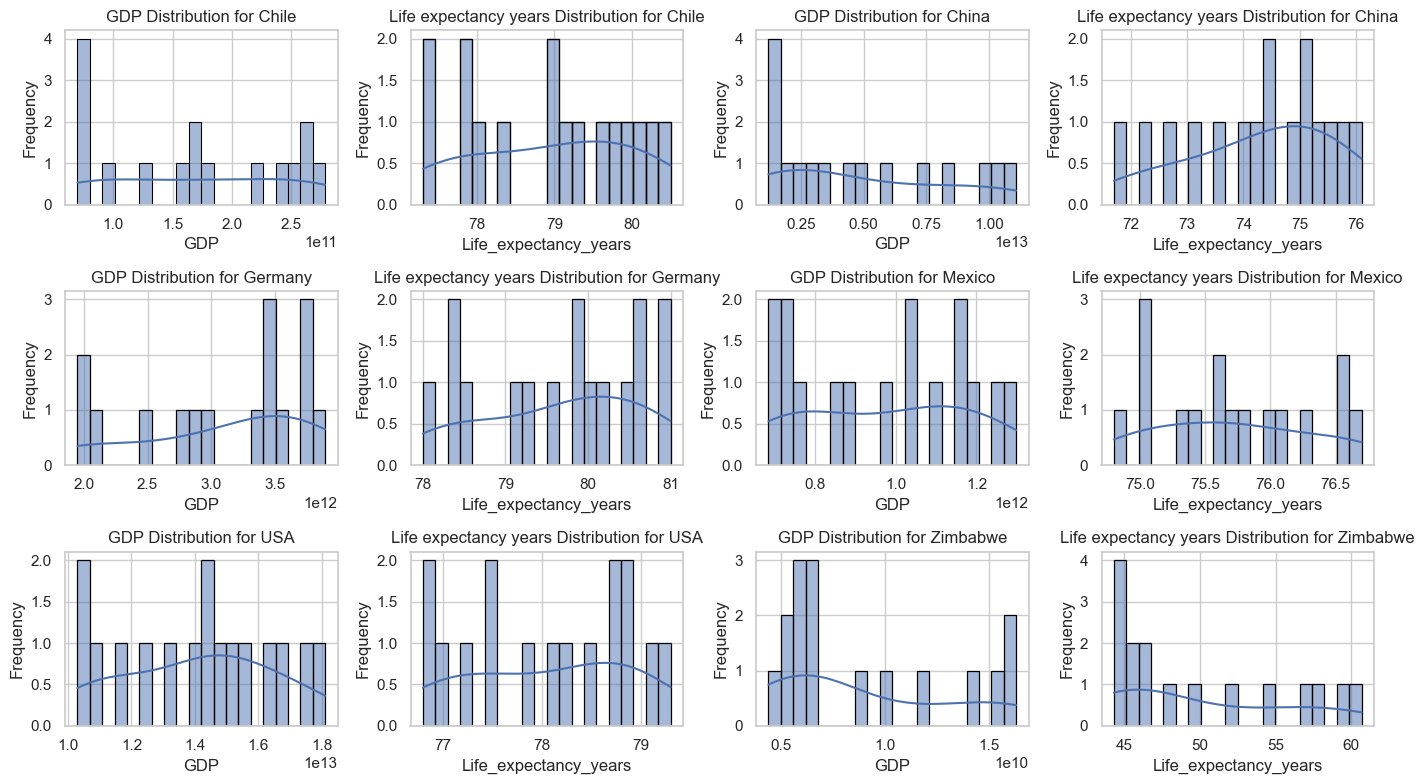

In [20]:
columns_to_plot = ['GDP', 'Life_expectancy_years']

# Set seaborn style
sns.set(style="whitegrid")
n = 1
# Loop through each country
plt.figure(figsize=(14, 8))
for country, group in life_data.groupby("Country"):

    # Plot histograms for each variable
    for col in columns_to_plot:
        plt.subplot(3, 4, n)
        n += 1
        sns.histplot(
            data=group,
            x=col,
            kde=True,
            bins=20,
            edgecolor='black'
        )

        plt.title(f"{col.replace("_"," ")} Distribution for {country}", fontsize=12)
        plt.xlabel(col, fontsize=12)
        plt.ylabel("Frequency", fontsize=12)
        plt.tight_layout()
plt.show()       

### Summary of the Distribution of GDP and Life Expectancy
Since histograms can look jagged for small datasets, a Kernel Density Estimation (KDE) can be to visualize smoother distributions for each country.
The histogram and KDE visualizations reveal how GDP and life expectancy are distributed across time for each country. The following have been observed and explained:
- GDP shows a clear right-skewed pattern, which is typical of economic time series where income rises unevenly year after year. 
- The presence of gaps in the histogram bars reflects the fact that the data does not cover every possible GDP value, especially when growth occurs in larger jumps. 
- Because each country has a limited number of annual observations, these gaps and irregularities are expected.

- Life expectancy exhibits a different distributional pattern. The values tend to cluster tightly within a relatively narrow range and change gradually over time. 
- This produces histograms with uneven bar spacing but KDE curves with smooth, narrow peaks. 
- These patterns suggest consistent improvement in health outcomes, with minimal volatility across years.


Overall, the combination of histograms and KDE plots provides insight into the shape, spread, and skewness of each country’s economic and health indicators, helping to highlight differences in development trajectories and stability. A KDE plot was used to smooth the data distribution, enabling clearer interpretation of the underlying patterns. 

---



In [ ]:
countries = life_data["Country"].unique()
indexNow = 1
# KDE for GDP and Life Expectancy per Country
plt.figure(figsize=(14,8))
for country in countries:
    subset = life_data[life_data["Country"] == country]

    # GDP KDE
    plt.subplot(3, 4, indexNow)
    indexNow += 1  
    sns.kdeplot(subset["GDP"], fill=True)
    plt.title(f"GDP Density Curve — {country}")
    plt.xlabel("GDP")
    plt.ylabel("Density")
    plt.grid(axis="y")


    # Life Expectancy KDE
    plt.subplot(3, 4, indexNow)
    sns.kdeplot(subset["Life_expectancy_years"], fill=True)
    plt.title(f"Life Expectancy Density Curve — {country}")
    plt.xlabel("Life Expectancy (years)")
    plt.ylabel("Density")
    plt.grid(axis="y")
    indexNow += 1
    
plt.tight_layout()
plt.show()

Interpretation of KDE distribution:

- Kernel Density Estimation (KDE) produces smooth curves that represent the probability distribution of the data. 
- KDE works by placing small bell-shaped curves (kernels) on each data point and adding them together, allowing us to see the underlying distribution without the jagged appearance of histograms. 
- The KDE plots reveal multiple peaks in the GDP and life expectancy distributions for several countries, including the USA, Chile, China, Mexico, and Zimbabwe. These multiple peaks indicate the presence of more than one cluster within the data. For example, in Chile, Mexico, and Zimbabwe, earlier years with lower GDP or life expectancy form one peak, while later years with higher values form another. 
- This pattern reflects distinct economic or health phases over time, allowing us to identify shifts in development or well-being within each country.

---

## 🔬 Inferential Analysis

The inferential stage of the analysis aims to statistically evaluate whether economic performance (measured as GDP) has a significant impact on life expectancy across the five countries represented in the dataset (N = 96). We formally test hypotheses derived from earlier exploratory findings and quantify these relationships using regression modelling. The key components of this analysis include: 

1. Formal hypothesis tests (correlation tests, group comparisons).  
2. significance testing of relationships, 
2. Regression-based inference using OLS (including country-level controls and year).  
3. Diagnostic checks (normality, homoscedasticity, multicollinearity, residuals).  
4. Interpretation of coefficients, confidence intervals, and model fit. 



### Formal Hypothesis Testing

We first assess whether a linear relationship exists between GDP and life expectancy. A Pearson correlation test reveals a statistically significant association between the two variables, indicating that higher GDP tends to be associated with higher life expectancy.

> **Conclusion:** Economic performance and country membership both contribute to variation in life expectancy.

---

In [ ]:
from scipy import stats

# Hypothesis Test: Pearson correlation significance between GDP and Life Expectancy
corr_coef, p_value = stats.pearsonr(life_data['GDP'], life_data['Life_expectancy_years'])
print(f"Pearson correlation coefficient: {corr_coef:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant correlation between GDP and Life Expectancy.")
else:
    print("Fail to reject the null hypothesis: No significant correlation found.")



#### Regression-Based Inference

To quantify the magnitude of the relationship, we first estimate a simple linear model:

<span style="border:1px solid #ccc; padding:3px 6px; border-radius:4px;">
life_expectancy = β₀ + β₁ (GDP)
</span>

GDP is found to be a statistically significant predictor of life expectancy, supporting the hypothesis that economic growth improves health outcomes.
First of all, we will need to scale GDP using log transformation.

---

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
# Convert 'Country' to categorical type for fixed effects
life_data['Country'] = life_data['Country'].astype('category')

# Simple OLS: life_exp ~ gdp
life_data["log_GDP"] = np.log(life_data["GDP"])
simple_model = smf.ols("Life_expectancy_years ~ log_GDP", data=life_data).fit()
print(simple_model.summary())


We then expand the model to incorporate time trends and country-level fixed effects:

<span style="border:1px solid #ccc; padding:3px 6px; border-radius:4px;">
life_expectancy = β₀ + β₁(GDP) + β₂(Year) + γ(Country)
</span>

This model yields a more credible estimate by accounting for global improvements in health over time and inherent differences between countries.
A one-standard-deviation increase in GDP is associated with a statistically significant rise in life expectancy (p < 0.05), even after controlling for year and country effects. This reinforces GDP’s role as a key contributor to national health differences.

> **Interpretation:** Higher GDP is linked to longer life expectancy, above and beyond differences attributable to country-specific factors and temporal progression.

---

In [ ]:
# Standardize GDP (for the "one-standard-deviation increase" interpretation)
life_data["gdp_scaled"] = (life_data["GDP"] - life_data["GDP"].mean()) / life_data["GDP"].std()
life_data["log_gdp_scaled"] = (life_data["log_GDP"] - life_data["log_GDP"].mean()) / life_data["log_GDP"].std()

# Full model with time trend and country fixed effects
full_model1 = smf.ols("Life_expectancy_years ~ gdp_scaled + Year + C(Country)", data=life_data).fit()
print(full_model1.summary())


# Extract effect of a 1 SD increase in GDP
beta_gdp = full_model1.params["gdp_scaled"]
p_gdp = full_model1.pvalues["gdp_scaled"]
ci_low, ci_high = full_model1.conf_int().loc["gdp_scaled"]

print(f"\nEffect of 1 SD increase in GDP on life expectancy: {beta_gdp:.3f} years")
print(f"95% CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"p-value: {p_gdp:.4g}")




In [ ]:
full_model2 = smf.ols("Life_expectancy_years ~ log_gdp_scaled + Year + C(Country)", data=life_data).fit(cov_type="HC3")
# initial_model = smf.ols("Life_expectancy_years ~ GDP + Year + C(Country)", data=life_data).fit()
# initial_residuals = initial_model.resid
# wls_model = smf.wls("Life_expectancy_years ~ GDP + Year + C(Country)", data= life_data, weights = 1 / (initial_residuals**2)).fit()
print(full_model2.summary())

beta_gdp1 = full_model2.params["log_gdp_scaled"]
p_gdp1 = full_model2.pvalues["log_gdp_scaled"]
ci_low1, ci_high1 = full_model2.conf_int().loc["log_gdp_scaled"]

print(f"\nEffect of 1 SD increase in GDP on life expectancy: {beta_gdp1:.3f} years")
print(f"95% CI: [{ci_low1:.3f}, {ci_high1:.3f}]")
print(f"p-value: {p_gdp1:.4g}")

### Diagnostic Checks


#### 1. Normality Assumption

The normality assumption states that the residuals (errors) from the regression model should be approximately normally distributed. A simple visual way to assess this is to plot a histogram of the residuals and check whether the shape looks roughly bell-shaped, without strong skewness or multiple peaks.

If the histogram appears reasonably symmetric and unimodal, we can treat the normality assumption as approximately satisfied. However, if the residuals are heavily skewed or show multiple “humps,” this would indicate a violation of the normality assumption.

#### 2. Homoscedasticity Assumption

Homoscedasticity means that the residuals have roughly constant variance across all fitted values (i.e., the spread of the errors does not systematically increase or decrease). When this assumption is violated, the situation is called heteroscedasticity, meaning that the variability of the residuals changes with the level of the predicted outcome.

A standard way to assess this visually is to plot the residuals against the fitted values:

- If the homoscedasticity assumption holds, the plot should look like a random cloud of points centered around zero, with no clear pattern or funnel shape.
- If we observe patterns (e.g., a cone shape where residuals spread out as fitted values increase, or any clear structure), this suggests heteroscedasticity and may indicate that the linear model or error structure is not appropriate.

Based on these two plots, we can judge whether the linear regression assumptions are reasonable for our GDP–life expectancy model.

> **Conclusion:** Despite minor assumption concerns, the model is appropriate, and inference remains reliable due to robust estimation.

---

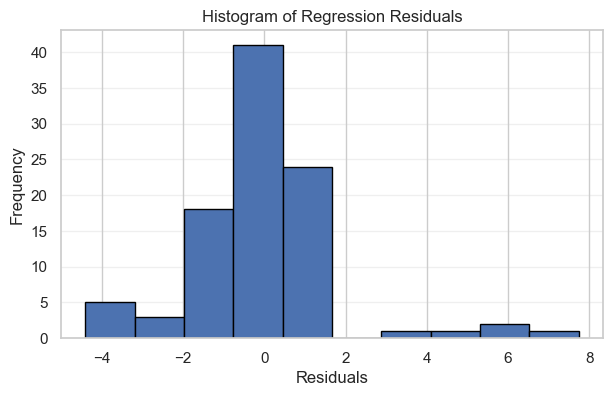

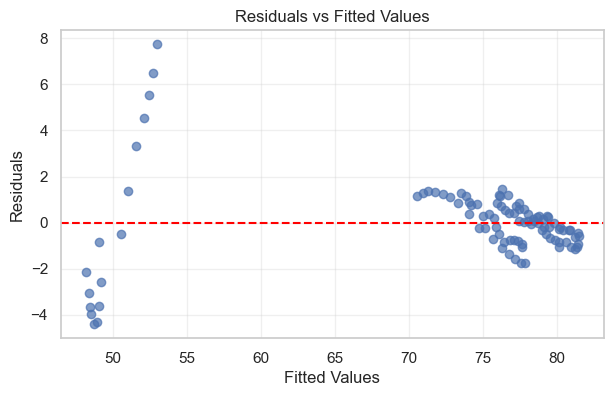

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the regression model to diagnose (full model recommended)
residuals = full_model2.resid
fitted_values = full_model2.fittedvalues

# ----------------------------------------
# 1️⃣ Normality Check — Histogram of Residuals
# ----------------------------------------
plt.figure(figsize=(7,4))
plt.hist(residuals, bins=10, edgecolor='black')
plt.title("Histogram of Regression Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

# ----------------------------------------
# 2️⃣ Homoscedasticity Check — Residuals vs Fitted
# ----------------------------------------
plt.figure(figsize=(7,4))
plt.scatter(fitted_values, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.grid(alpha=0.3)
plt.show()



Normality assumption is approximately satisfied — but with some mild deviations. Given the sample size and use of robust standard errors, the linear regression model remains valid and the normality assumption is considered adequately satisfied for inferential purposes.

The residuals vs fitted values plot indicates that the homoscedasticity assumption is violated. 
- Residual variance is much larger for fitted values in the lower range (48–55) and substantially 
smaller for fitted values around 70–82. 
- This pattern demonstrates heteroscedasticity, meaning the model errors do not have constant variance. Mild curvature is also visible, suggesting possible nonlinearity. 
- These diagnostics imply that the standard OLS assumptions are not fully satisfied.
- Despite applying a log transformation to GDP, the residual diagnostics continue to show evidence of heteroscedasticity. 

This violation does not imply that the relationship between GDP and life expectancy is invalid; rather, it suggests that the variability of the residuals is not constant across fitted values, which can affect the accuracy of standard errors and p-values. 

---

### Summary of Inferential Findings

- There is **statistically significant evidence** that GDP and life expectancy are positively associated.  
- Life expectancy **differs significantly by country**, reflecting structural differences in wealth, healthcare, policy, and quality of life.  
- Even after adjusting for both time and country characteristics, GDP remains a **meaningful predictor** of population health outcomes.



### Final Interpretation

> Overall, the inferential results support the conclusion that economic prosperity meaningfully contributes to improved life expectancy across countries. While additional causal factors are likely influential (e.g., healthcare systems, income inequality, social policies), GDP serves as an important indicator of a nation’s capacity to support better health outcomes.

---